# Belief Model — Evaluation & Interpretability

Quantitative evals (BCE, MAE, MSE, Perplexity, AUC-ROC, Sharpe) and interpretability visualizations
(attention heatmaps, attention entropy, calibration, belief PCA) for the Architecture3 transformer.

In [1]:
import sys
from pathlib import Path

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT / "src"))

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [2]:
CHECKPOINT   = ROOT / "runs/belief/test_belief_model.pt"
WORLD_CONFIG = ROOT / "configs/default.yaml"
N_EPISODES   = 500
DEVICE       = torch.device("cpu")

## Load Model & Generate Eval Data

In [3]:
from model.evaluate import load_model, generate_eval_episodes, run_model_on_episodes, compute_metrics
from model.visualize import (
    plot_attention_heatmaps,
    plot_per_head_attention,
    plot_attention_entropy,
    plot_sharpe_vs_time,
    plot_calibration,
    plot_belief_pca,
)
from deep_belief_betting.simulation.parameters import Parameters

model, cfg = load_model(CHECKPOINT, DEVICE)
print(f"Model loaded | T={cfg.T}  d_z={cfg.d_z}  n_layers={cfg.n_layers}  n_heads={cfg.n_heads}")
print(f"enable_true_prob_head: {cfg.enable_true_prob_head}")

Model loaded | T=64  d_z=16  n_layers=2  n_heads=4
enable_true_prob_head: True


In [4]:
params = Parameters.from_yaml(WORLD_CONFIG)
features, latent_targets, terminal_labels = generate_eval_episodes(params, N_EPISODES, cfg.T)
print(f"features: {features.shape}  latent_targets: {latent_targets.shape}  terminal_labels: {terminal_labels.shape}")
print(f"YES rate: {terminal_labels.mean():.3f}")

features: (500, 65, 2)  latent_targets: (500, 65)  terminal_labels: (500,)
YES rate: 0.494


In [5]:
p_latent, p_terminal, z_final = run_model_on_episodes(model, features, DEVICE)
metrics = compute_metrics(p_latent, latent_targets, p_terminal, terminal_labels)
print("Done.")

Done.


---
## Quantitative Metrics

In [6]:
lh = metrics["latent_head"]
print("=== Latent Head (p_t vs latent_probability) ===")
print(f"  BCE : {lh['bce']:.4f}")
print(f"  MAE : {lh['mae']:.4f}")
print(f"  MSE : {lh['mse']:.4f}")

if "terminal_head" in metrics:
    th = metrics["terminal_head"]
    print()
    print("=== Terminal Head (out_t vs terminal_label) ===")
    print(f"  BCE        : {th['bce']:.4f}")
    print(f"  Perplexity : {th['perplexity']:.4f}")
    print(f"  MAE        : {th['mae']:.4f}")
    print(f"  MSE        : {th['mse']:.4f}")
    print(f"  AUC-ROC    : {th['auc_roc_final_step']:.4f}")

print()
print("=== Sharpe ===")
print(f"  Final step : {metrics['sharpe_final']:.4f}")
print(f"  Max        : {metrics['sharpe_max']:.4f}  (t={metrics['sharpe_max_timestep']})")

=== Latent Head (p_t vs latent_probability) ===
  BCE : 0.6677
  MAE : 0.1365
  MSE : 0.0291

=== Terminal Head (out_t vs terminal_label) ===
  BCE        : 0.6143
  Perplexity : 1.8484
  MAE        : 0.4159
  MSE        : 0.2141
  AUC-ROC    : 0.9310

=== Sharpe ===
  Final step : 1.1116
  Max        : 1.1779  (t=63)


---
## Sharpe Ratio vs Timestep

At each timestep *t*, uses the model's p_t as a directional signal (sign(p_t − 0.5)) and computes
the Sharpe of the resulting return against the true terminal outcome.

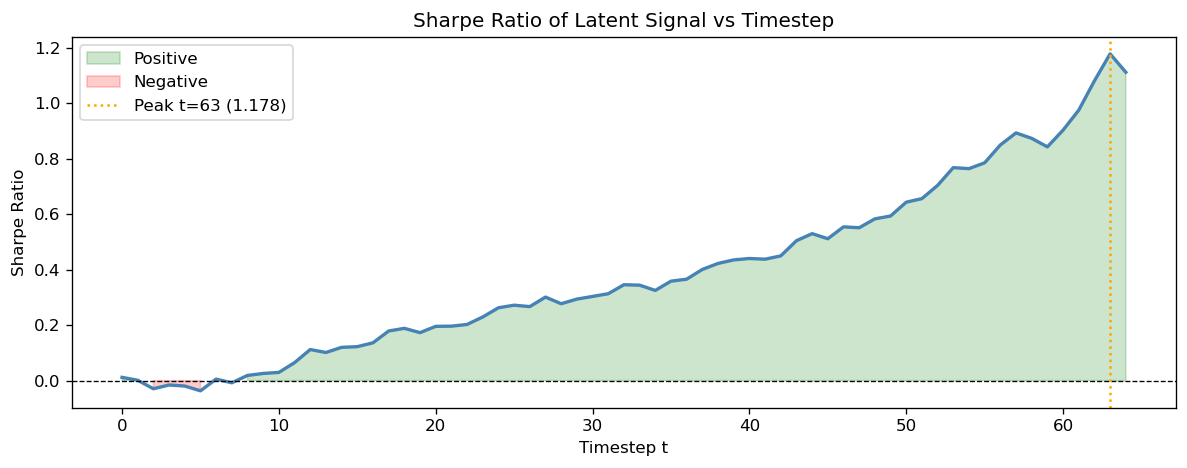

In [7]:
fig = plot_sharpe_vs_time(metrics["sharpe_by_timestep"])
plt.show()

---
## Calibration Curve

Predicted p_t bucketed into 10 bins vs mean empirical latent probability in each bin.
The diagonal is perfect calibration.

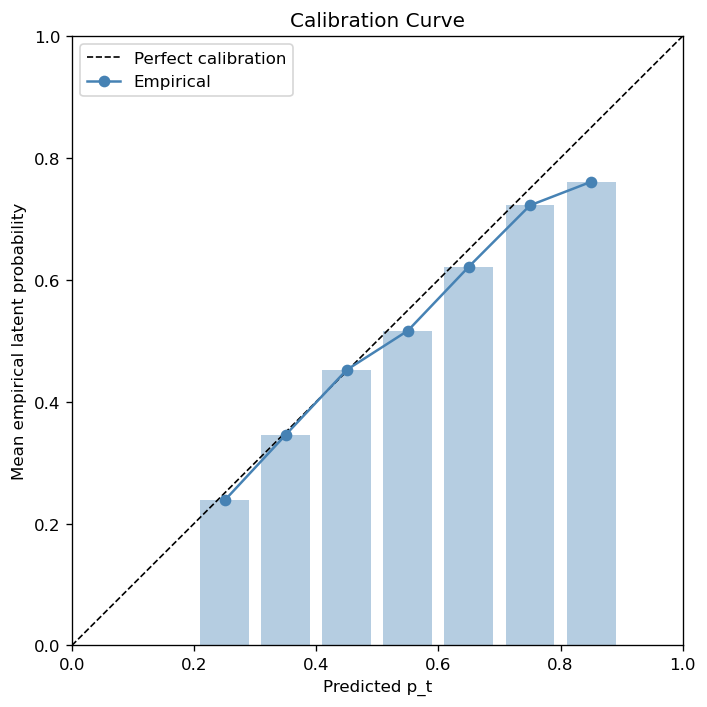

In [8]:
fig = plot_calibration(metrics)
plt.show()

---
## Attention Heatmaps — All Layers (avg over heads)

Each subplot is the (L × L) attention weight matrix for one encoder layer, averaged
across all heads. Lower-left triangle is causal mask (zeros). Brighter = more attention.

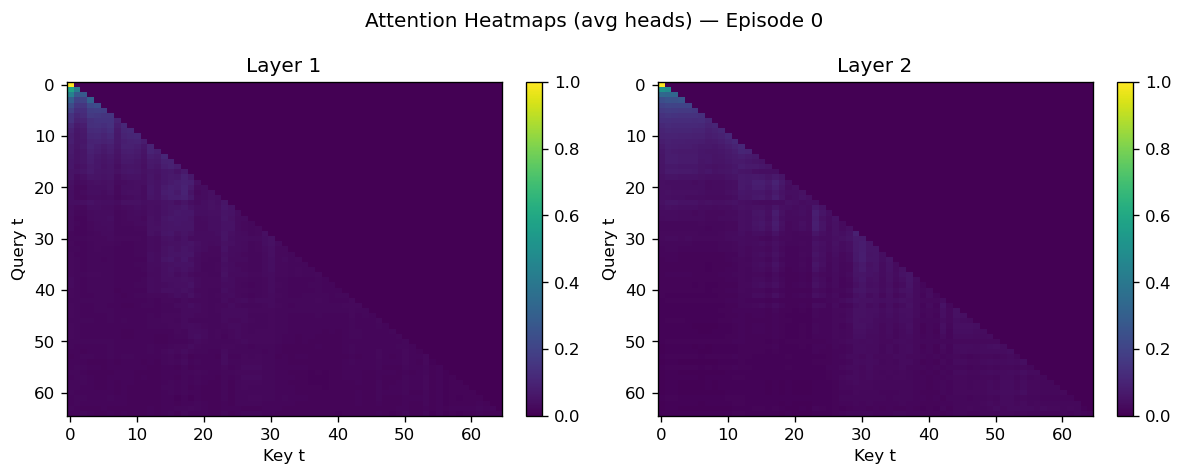

In [9]:
EPISODE_IDX = 0
fig = plot_attention_heatmaps(model, features, episode_idx=EPISODE_IDX, device=DEVICE)
plt.show()

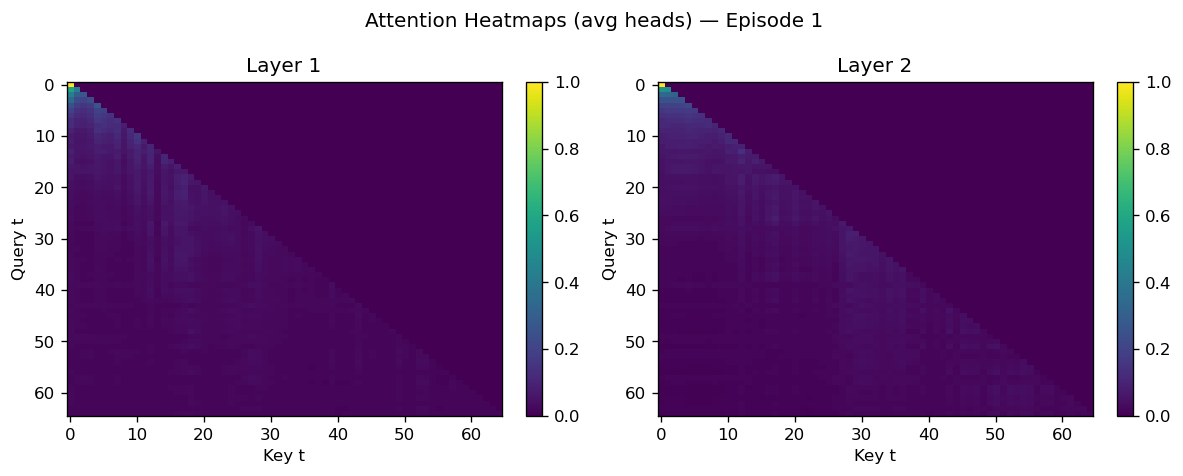

In [10]:
fig = plot_attention_heatmaps(model, features, episode_idx=1, device=DEVICE)
plt.show()

---
## Per-Head Attention — Layer 1

Individual attention heads within a single layer. Reveals head specialization —
some heads may attend locally (diagonal), others globally.

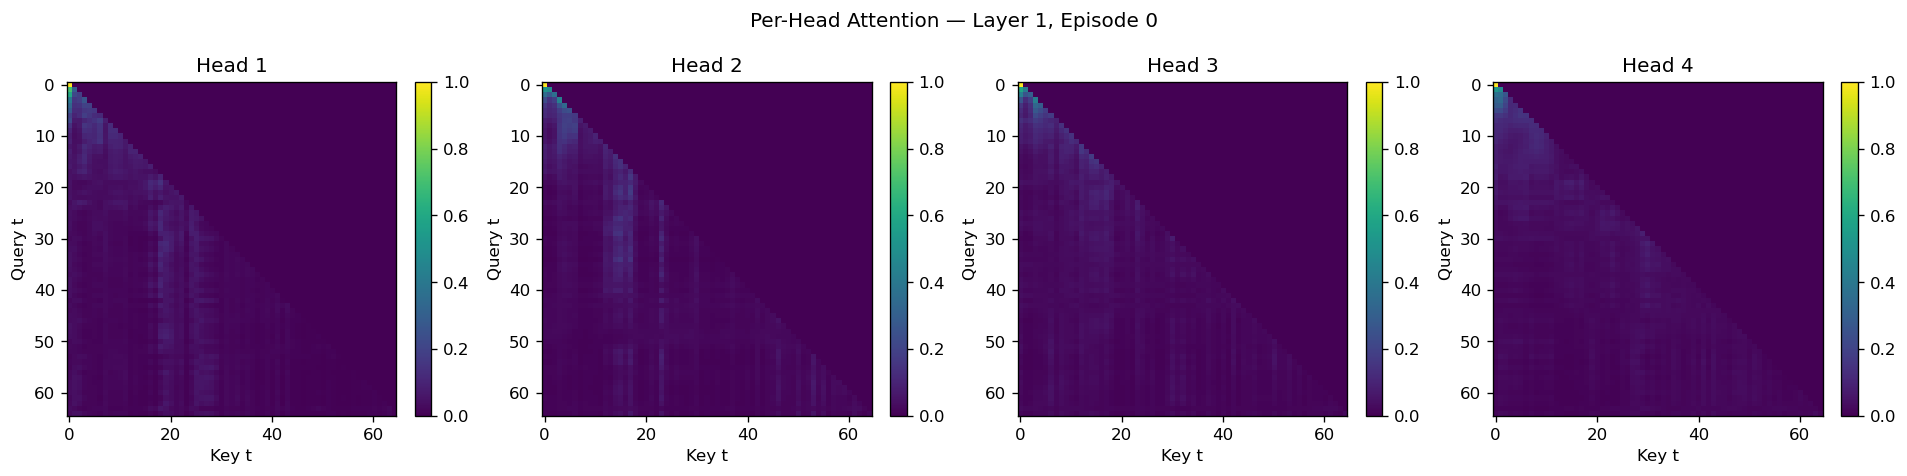

In [11]:
fig = plot_per_head_attention(model, features, episode_idx=EPISODE_IDX, layer_idx=0, device=DEVICE)
plt.show()

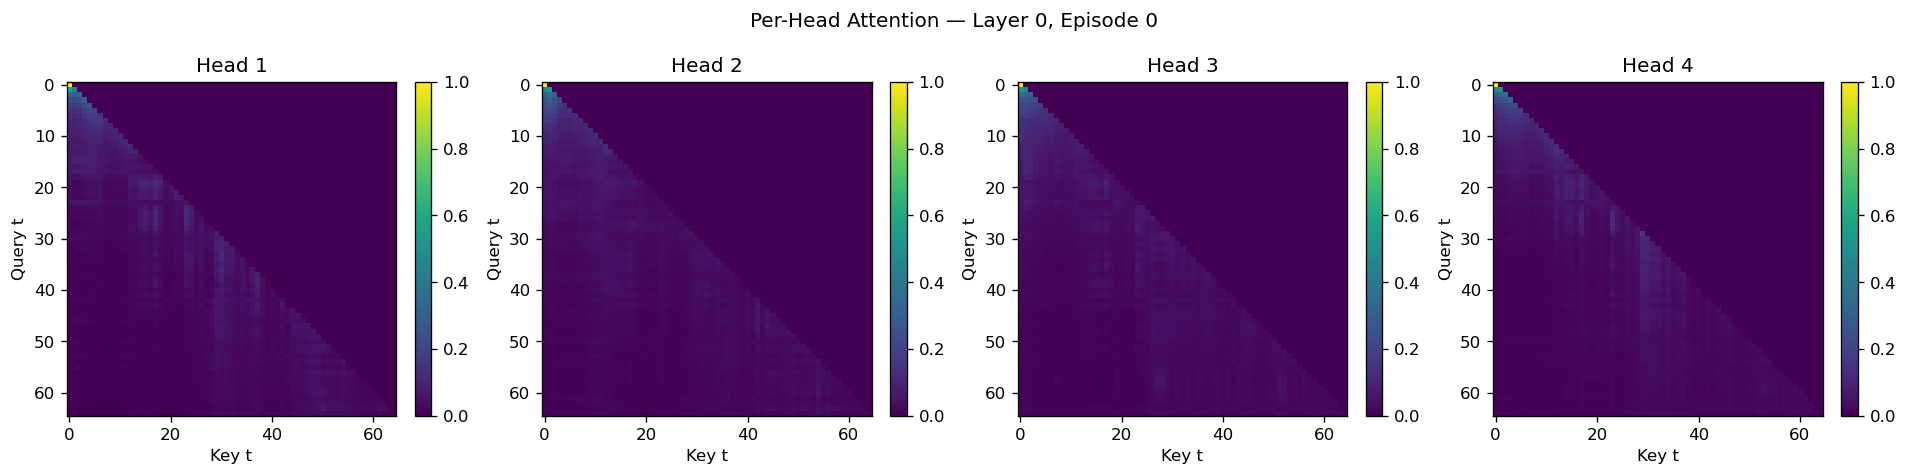

In [12]:
fig = plot_per_head_attention(model, features, episode_idx=EPISODE_IDX, layer_idx=-1, device=DEVICE)
plt.show()

---
## Attention Entropy per Head per Layer

Average entropy of each head's attention distribution across eval episodes.
High entropy = diffuse (attends broadly). Low entropy = sharp (attends to few tokens).

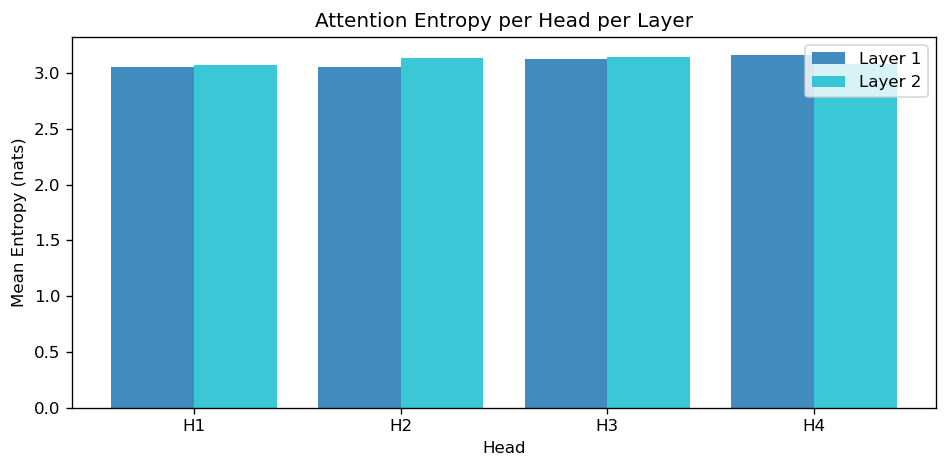

In [13]:
fig = plot_attention_entropy(model, features, n_episodes=min(100, N_EPISODES), device=DEVICE)
plt.show()

---
## Belief Vector PCA

PCA projection of the final latent state vectors z_T (one per episode) to 2D.
Color encodes terminal outcome. Separation indicates the model has learned
outcome-predictive structure in its latent space.

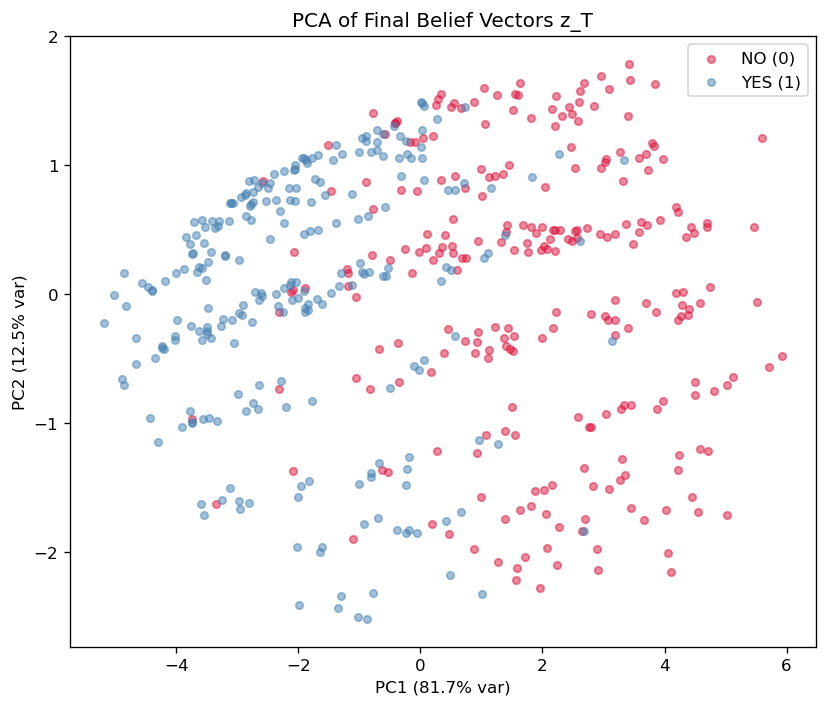

In [14]:
fig = plot_belief_pca(z_final, terminal_labels)
plt.show()